# Experimento 03

## Adaptación de todas las capas convolucionales para sesgar hacia frecuencia

In [1]:
%%capture
from framework.framework_final import Persister, MetricsCalculator, AudioResNetModel, GSC, Preprocessor, Trainer, Evaluator, prepare_batch, plot_curves, show_image_grid, signal_grad_cam_overlays2d
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import numpy as np
from typing import List, Dict, Any, Optional
import pandas as pd
from sklearn.preprocessing import LabelEncoder

from signal_grad_cam.pytorch_cam_builder import TorchCamBuilder

I0000 00:00:1780888198.266636    1940 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780888198.297288    1940 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780888199.114626    1940 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780888199.114886    1940 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
AUDIO_PATH = Path('/mnt/data/GSC/normalized-dataset')
XTRAIN_PATH = Path('./dataframes/FASE2-X_train.csv')
XTEST_PATH = Path('./dataframes/FASE2-X_test.csv')
XVAL_PATH = Path('./dataframes/FASE2-X_val.csv')
YVAL_PATH = Path('./dataframes/FASE2-y_val.csv')
YTRAIN_PATH = Path('./dataframes/FASE2-y_train.csv')
YTEST_PATH = Path('./dataframes/FASE2-y_test.csv')
BACKGROUND_NOISES = sorted(Path(f"/mnt/data/GSC/speech_commands_v0.02/_background_noise_/").glob('*wav'))

NUM_CLASSES = 35

DEVICE = 'cuda'

SAMPLE_RATE = 16000
N_MELS = 64
N_FFT = int(400)
WIN_LENGTH = N_FFT
HOP_LENGTH = int(WIN_LENGTH/2)

In [3]:
final_path = '03-experimento_03/final'
checkpoints_path = '03-experimento_03/checkpoints'
xai_path = Path('/mnt/data/GSC/XAI/03-experimento_03')
batch_size = 64
epochs = 10

In [4]:
%%capture
# Instanciación del framework
persister = Persister(final_path=final_path, checkpoints_path=checkpoints_path, xai_path=xai_path)
preprocessor_train = Preprocessor(
        sample_rate = SAMPLE_RATE,
        n_mels = N_MELS,
        win_length = WIN_LENGTH,
        hop_length = HOP_LENGTH,
        n_fft = N_FFT,
        with_log = True,
        device = DEVICE,
        mode = "training")

preprocessor_test = Preprocessor(
        sample_rate = SAMPLE_RATE,
        n_mels = N_MELS,
        win_length = WIN_LENGTH,
        hop_length = HOP_LENGTH,
        n_fft = N_FFT,    
        with_log = True,
        device = DEVICE)
# Modelo
model = AudioResNetModel(dims=2, num_classes=NUM_CLASSES).get_model()
#-> CAMBIO Adaptamos capa a capa el modelo:
model.conv1 = nn.Conv2d(1, 64, kernel_size=(5,3), stride=(1,1), padding=(2,1), bias=False)
model.maxpool = nn.MaxPool2d(kernel_size=(1,3),stride=(1,2),padding=(0,1))

model.layer1[0].conv1 = nn.Conv2d(64, 64, kernel_size=(5,3), stride=(1,1), padding=(2,1), bias=False)
model.layer1[0].conv2 = nn.Conv2d(64, 64, kernel_size=(3,3), stride=(1,1), padding=(1,1), bias=False)
model.layer1[1].conv1 = nn.Conv2d(64, 64, kernel_size=(5,3), stride=(1,1), padding=(2,1), bias=False)
model.layer1[1].conv2 = nn.Conv2d(64, 64, kernel_size=(3,3), stride=(1,1), padding=(1,1), bias=False)

model.layer2[0].conv1 = nn.Conv2d(64, 128, kernel_size=(5,3), stride=(1,2), padding=(2,1), bias=False)
model.layer2[0].conv2 = nn.Conv2d(128, 128, kernel_size=(3,3), stride=(1,1), padding=(1,1), bias=False)
model.layer2[0].downsample[0] = nn.Conv2d(64, 128, kernel_size=(1,1), stride=(1,2), bias=False)

model.layer2[1].conv1 = nn.Conv2d(128, 128, kernel_size=(5,3), stride=(1,1), padding=(2,1), bias=False)
model.layer2[1].conv2 = nn.Conv2d(128, 128, kernel_size=(3,3), stride=(1,1), padding=(1,1), bias=False)

model.layer3[0].conv1 = nn.Conv2d(128, 256, kernel_size=(5,3), stride=(1,2), padding=(2,1), bias=False)
model.layer3[0].conv2 = nn.Conv2d(256, 256, kernel_size=(3,3), stride=(1,1), padding=(1,1), bias=False)
model.layer3[0].downsample[0] = nn.Conv2d(128, 256, kernel_size=(1,1), stride=(1,2), bias=False)

model.layer3[1].conv1 = nn.Conv2d(256, 256, kernel_size=(3,3), stride=(1,1), padding=(1,1), bias=False)
model.layer3[1].conv2 = nn.Conv2d(256, 256, kernel_size=(3,3), stride=(1,1), padding=(1,1), bias=False)

model.layer4[0].conv1 = nn.Conv2d(256, 512, kernel_size=(5,3), stride=(1,2), padding=(2,1), bias=False)
model.layer4[0].downsample[0] = nn.Conv2d(256, 512, kernel_size=(1,1), stride=(1,2), bias=False)

model.layer4[1].conv1 = nn.Conv2d(512, 512, kernel_size=(5,3), stride=(1,1), padding=(2,1), bias=False)
model.layer4[1].conv2 = nn.Conv2d(512, 512, kernel_size=(3,3), stride=(1,1), padding=(1,1), bias=False)

model.to(DEVICE)

In [5]:
# Conjuntos de datos
X_train = pd.read_csv(XTRAIN_PATH)
X_test = pd.read_csv(XTEST_PATH)
y_train = pd.read_csv(YTRAIN_PATH)
y_test = pd.read_csv(YTRAIN_PATH)
X_val = pd.read_csv(XVAL_PATH)                                                                                                          
y_val = pd.read_csv(YVAL_PATH)                                                                                                          

le = LabelEncoder()

y_encoded = le.fit_transform(y_train['keyword'])
ytest_encoded = le.transform(y_test['keyword'])
yval_encoded = le.transform(y_val['keyword'])

label_names= le.classes_

train_list = X_train['path_normalized'].tolist()                                                                                            
train_labels = y_encoded.tolist() 
val_list = X_val['path_normalized'].tolist()                                                                                            
val_labels = yval_encoded.tolist() 
test_list = X_test['path_normalized'].tolist()
test_labels = ytest_encoded.tolist()

train_dataset = GSC(file_list=train_list, labels=train_labels)
validation_dataset = GSC(file_list=val_list, labels=val_labels)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=prepare_batch, num_workers=4)
val_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False, collate_fn=prepare_batch, num_workers=4)
test_dataset = GSC(test_list, test_labels)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False, collate_fn = prepare_batch, num_workers = 4)

In [6]:
trainer = Trainer(model=model, train_loader=train_loader, val_loader=val_loader, preprocessor=preprocessor_train, persister=persister, device=DEVICE, epochs=5)                        
trainer.fit(resume=False)

Epoch::   0%|          | 0/5 [00:00<?, ?it/s]

Batches entrenamiento:   0%|          | 0/1158 [00:00<?, ?it/s]

Batches validación:   0%|          | 0/166 [00:00<?, ?it/s]

Epoch 1/5
  Train - Pérdida: 1.2694, Accuracy: 0.6323, F1-score: 0.6171
  Val   - Pérdida: 0.9169, Accuracy: 0.7249, F1-score: 0.7160


Batches entrenamiento:   0%|          | 0/1158 [00:00<?, ?it/s]

...

Batches validación:   0%|          | 0/166 [00:00<?, ?it/s]

Epoch 4/5
  Train - Pérdida: 0.2520, Accuracy: 0.9228, F1-score: 0.9175
  Val   - Pérdida: 0.3161, Accuracy: 0.9046, F1-score: 0.8936


Batches entrenamiento:   0%|          | 0/1158 [00:00<?, ?it/s]

Batches validación:   0%|          | 0/166 [00:00<?, ?it/s]

Epoch 5/5
  Train - Pérdida: 0.2149, Accuracy: 0.9343, F1-score: 0.9297
  Val   - Pérdida: 0.3028, Accuracy: 0.9101, F1-score: 0.9011


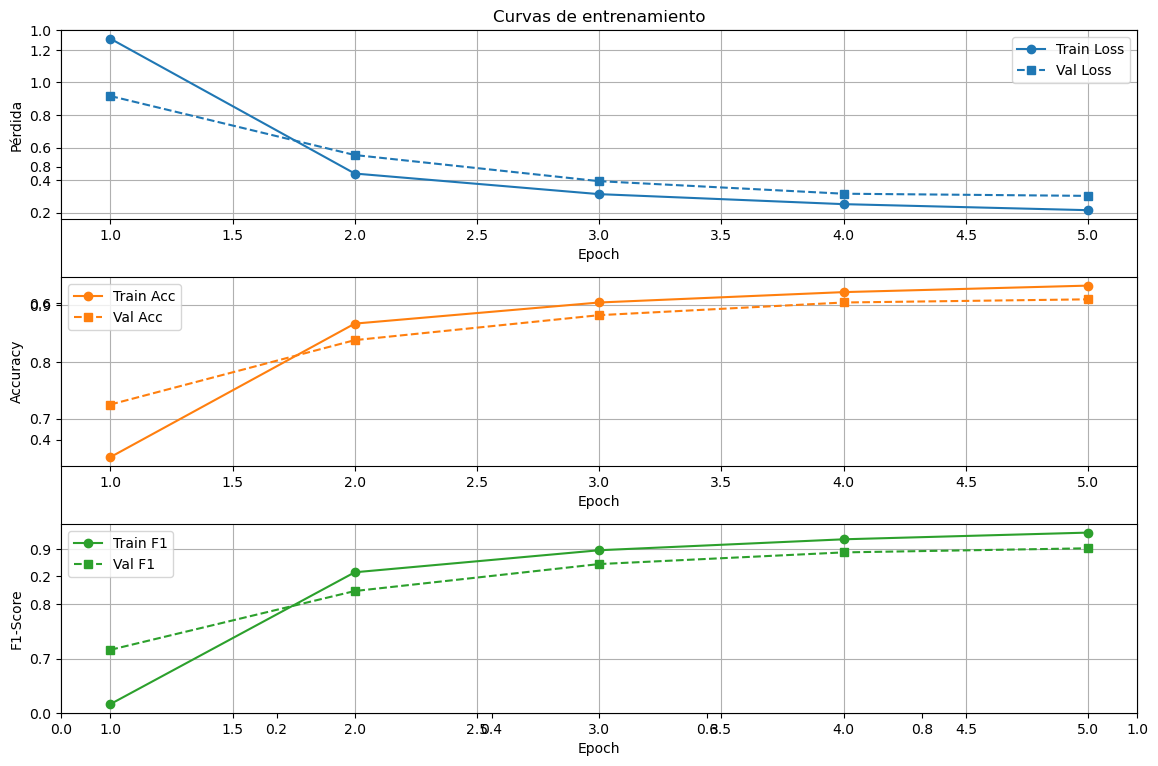

In [11]:
# Evaluación del modelo
# Cargamos desde el disco para poder evaluar en cualquier momento
loaded_pt = torch.load(f"{final_path}/final_model.pt", map_location=DEVICE)
loaded_model = AudioResNetModel(dims=2, num_classes=35).get_model()
#-> CAMBIO Adaptamos capa a capa el modelo:
loaded_model.conv1 = nn.Conv2d(1, 64, kernel_size=(5,3), stride=(1,1), padding=(2,1), bias=False)
loaded_model.maxpool = nn.MaxPool2d(kernel_size=(1,3),stride=(1,2),padding=(0,1))

loaded_model.layer1[0].conv1 = nn.Conv2d(64, 64, kernel_size=(5,3), stride=(1,1), padding=(2,1), bias=False)
loaded_model.layer1[0].conv2 = nn.Conv2d(64, 64, kernel_size=(3,3), stride=(1,1), padding=(1,1), bias=False)
loaded_model.layer1[1].conv1 = nn.Conv2d(64, 64, kernel_size=(5,3), stride=(1,1), padding=(2,1), bias=False)
loaded_model.layer1[1].conv2 = nn.Conv2d(64, 64, kernel_size=(3,3), stride=(1,1), padding=(1,1), bias=False)

loaded_model.layer2[0].conv1 = nn.Conv2d(64, 128, kernel_size=(5,3), stride=(1,2), padding=(2,1), bias=False)
loaded_model.layer2[0].conv2 = nn.Conv2d(128, 128, kernel_size=(3,3), stride=(1,1), padding=(1,1), bias=False)
loaded_model.layer2[0].downsample[0] = nn.Conv2d(64, 128, kernel_size=(1,1), stride=(1,2), bias=False)

loaded_model.layer2[1].conv1 = nn.Conv2d(128, 128, kernel_size=(5,3), stride=(1,1), padding=(2,1), bias=False)
loaded_model.layer2[1].conv2 = nn.Conv2d(128, 128, kernel_size=(3,3), stride=(1,1), padding=(1,1), bias=False)

loaded_model.layer3[0].conv1 = nn.Conv2d(128, 256, kernel_size=(5,3), stride=(1,2), padding=(2,1), bias=False)
loaded_model.layer3[0].conv2 = nn.Conv2d(256, 256, kernel_size=(3,3), stride=(1,1), padding=(1,1), bias=False)
loaded_model.layer3[0].downsample[0] = nn.Conv2d(128, 256, kernel_size=(1,1), stride=(1,2), bias=False)

loaded_model.layer3[1].conv1 = nn.Conv2d(256, 256, kernel_size=(3,3), stride=(1,1), padding=(1,1), bias=False)
loaded_model.layer3[1].conv2 = nn.Conv2d(256, 256, kernel_size=(3,3), stride=(1,1), padding=(1,1), bias=False)

loaded_model.layer4[0].conv1 = nn.Conv2d(256, 512, kernel_size=(5,3), stride=(1,2), padding=(2,1), bias=False)
loaded_model.layer4[0].downsample[0] = nn.Conv2d(256, 512, kernel_size=(1,1), stride=(1,2), bias=False)

loaded_model.layer4[1].conv1 = nn.Conv2d(512, 512, kernel_size=(5,3), stride=(1,1), padding=(2,1), bias=False)
loaded_model.layer4[1].conv2 = nn.Conv2d(512, 512, kernel_size=(3,3), stride=(1,1), padding=(1,1), bias=False)

loaded_model.load_state_dict(loaded_pt['model_state_dict'])
loaded_model.eval()

plot_curves(loaded_pt, 'Curvas de entrenamiento')

**Análisis del entrenamiento**

La evolución de las curvas con 5 epochs es bastante positiva y las métricas superan a las de la línea de base.

In [12]:
# Instanciamos el evaluador y computamos métricas
evaluator = Evaluator(model=loaded_model, device=DEVICE, test_loader=test_loader, preprocessor = preprocessor_test)
confusion_matrix, precission, recall, avg_loss, accuracy, f1, support = evaluator.eval()
print("Pérdida:", avg_loss, "Accuracy:", accuracy, "F1-Score:", f1)

Batches evaluación:   0%|          | 0/166 [00:00<?, ?it/s]

Pérdida: 0.6491507609953752 Accuracy: 0.8933093933093933 F1-Score: 0.8840160461772317


La métrica sobre el conjunto de test no es mucho mejor que en la línea de base, pero sólo hemos entrenado 5 epochs antes de la valoración por el alto coste de entrenamiento de este modelo.

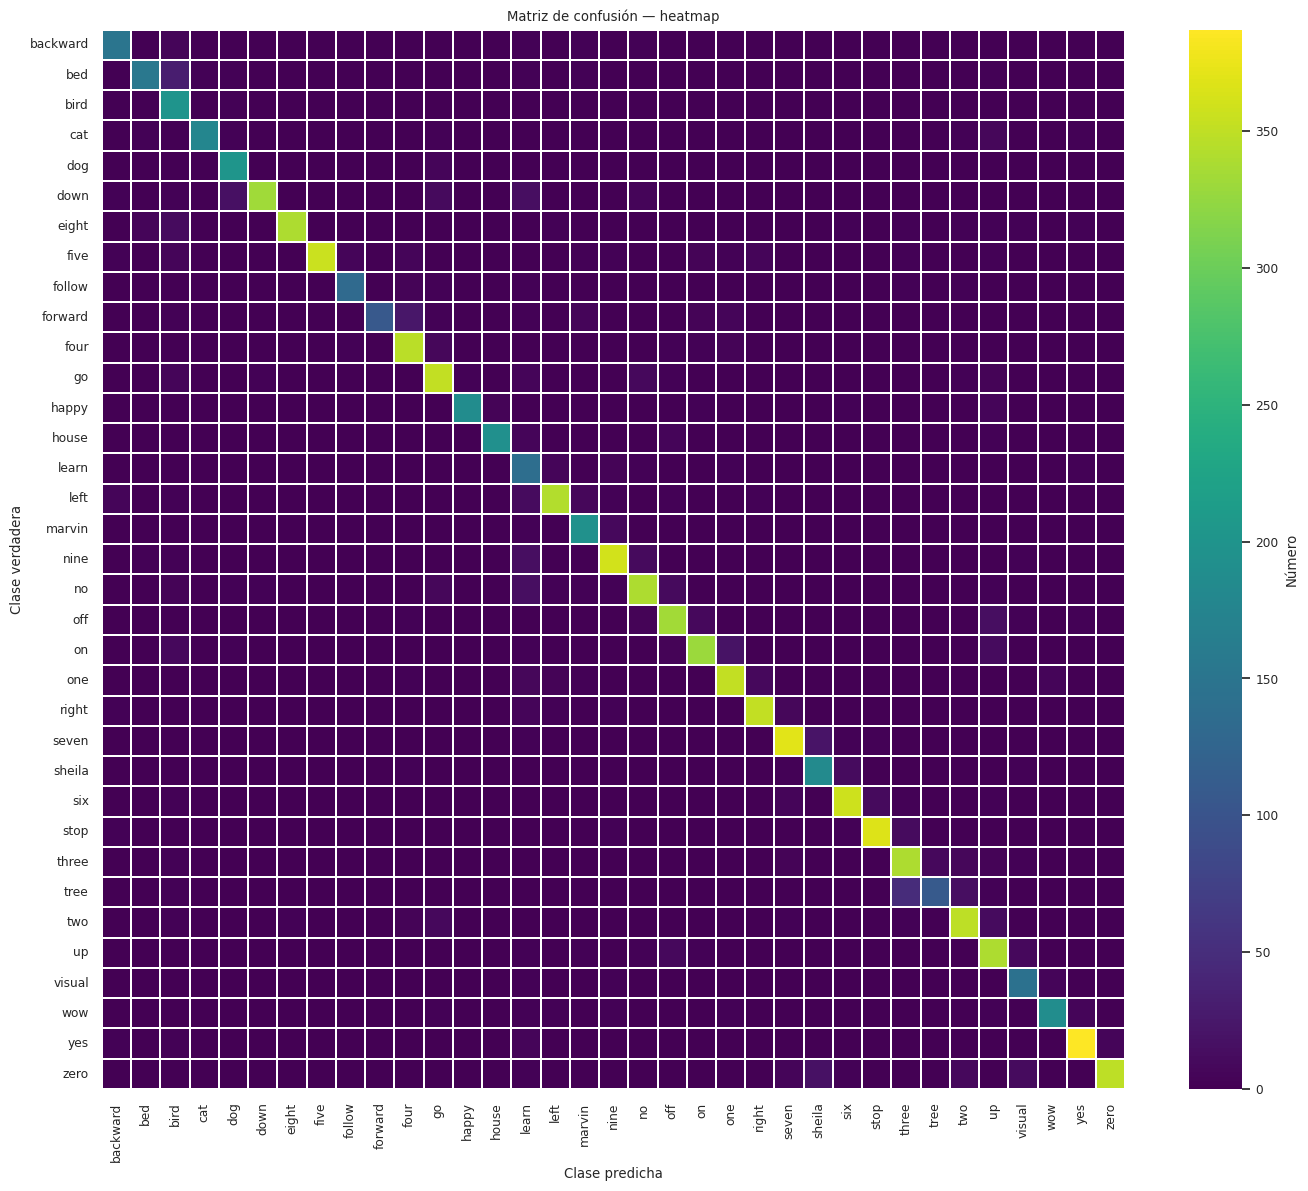

In [13]:
import matplotlib.pyplot as plt
import seaborn as sb

plt.figure(figsize = (14,12))
sb.set(font_scale = 0.8)
ax = sb.heatmap(confusion_matrix,
                annot=False,
                fmt = ".2f",
                cmap = "viridis",
                cbar_kws = {"label": "Número"},
                xticklabels = label_names,
                yticklabels = label_names,
                linewidths = 0.3,
                linecolor = "white")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.xlabel("Clase predicha")
plt.ylabel("Clase verdadera")
plt.title("Matriz de confusión — heatmap")
plt.tight_layout()
plt.show()
plt.rcdefaults()

No se aprecia ninguna concentración de errores especialmente llamativa.

In [14]:
print("Accuracy:", accuracy, "Precission:", precission, "Recall:", recall, "Pérdida media:", avg_loss, "F1-score:", f1)

Accuracy: 0.8933093933093933 Precission: 0.8925743509131916 Recall: 0.885569028299096 Pérdida media: 0.6491507609953752 F1-score: 0.8840160461772317


In [15]:
## Signal_grad_cam: Preparamos los datos
reference_samples = ['/mnt/data/GSC/normalized-dataset/go/012c8314_nohash_0.wav',
                    '/mnt/data/GSC/normalized-dataset/off/0227998e_nohash_0.wav',
                    '/mnt/data/GSC/normalized-dataset/left/016e2c6d_nohash_0.wav']
reference_labels = [11,19,15]

reference_dataset = GSC(reference_samples, reference_labels)
reference_loader = DataLoader(reference_dataset, batch_size = 3, shuffle = False, 
                              collate_fn = prepare_batch, num_workers = 4)

reference_targets = [11,19,15]

In [16]:
%%capture
## Generamos los CAMs
target_layers = ['layer4.1.conv2', 'layer4.0.conv2', 
                 'layer3.1.conv2', 'layer3.0.conv2', 
                 'layer2.1.conv2', 'layer1.1.conv2']

explainer = "Grad-CAM"

signal_grad_cam_overlays2d(model=loaded_model, dataloader=reference_loader, preprocessor=preprocessor_test,
                          xai_path=xai_path, label_names=label_names, explainer=explainer,
                          target_layers=target_layers, target_classes=reference_labels, 
                          targets_list=reference_targets)

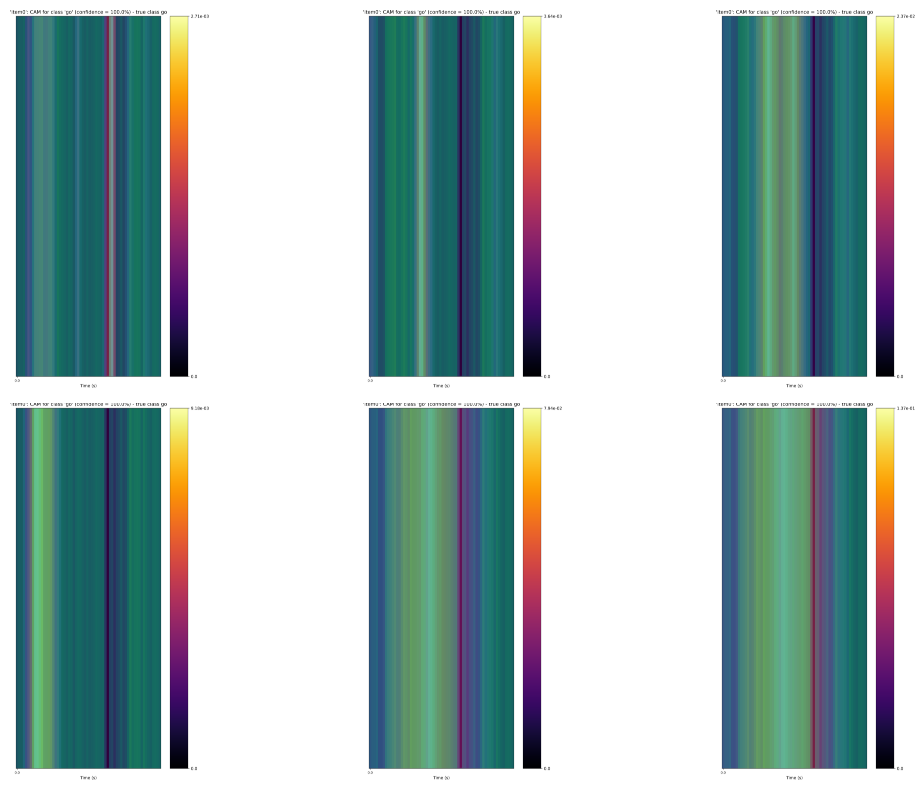

In [17]:
## Visualizamos muestra de capas
# "GO"
images_to_show = sorted(Path(f"{xai_path}/CAMs/overlays/0-2/item0/").glob("*Grad*.png"))
show_image_grid(images_to_show)

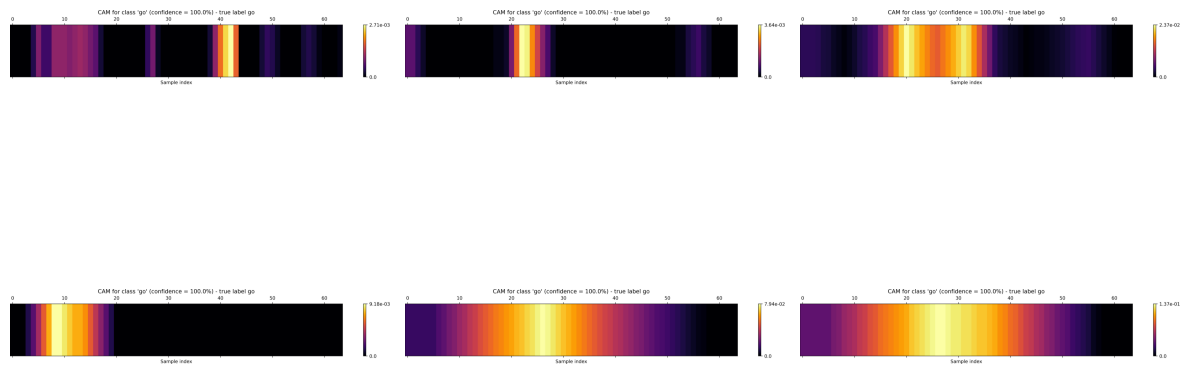

In [18]:
## Visualizamos sólo las CAMs
# "GO"
images_to_show = sorted(Path(f"{xai_path}/CAMs/0-2/item0/").glob("*Grad-CAM*11.png"))
show_image_grid(images_to_show)

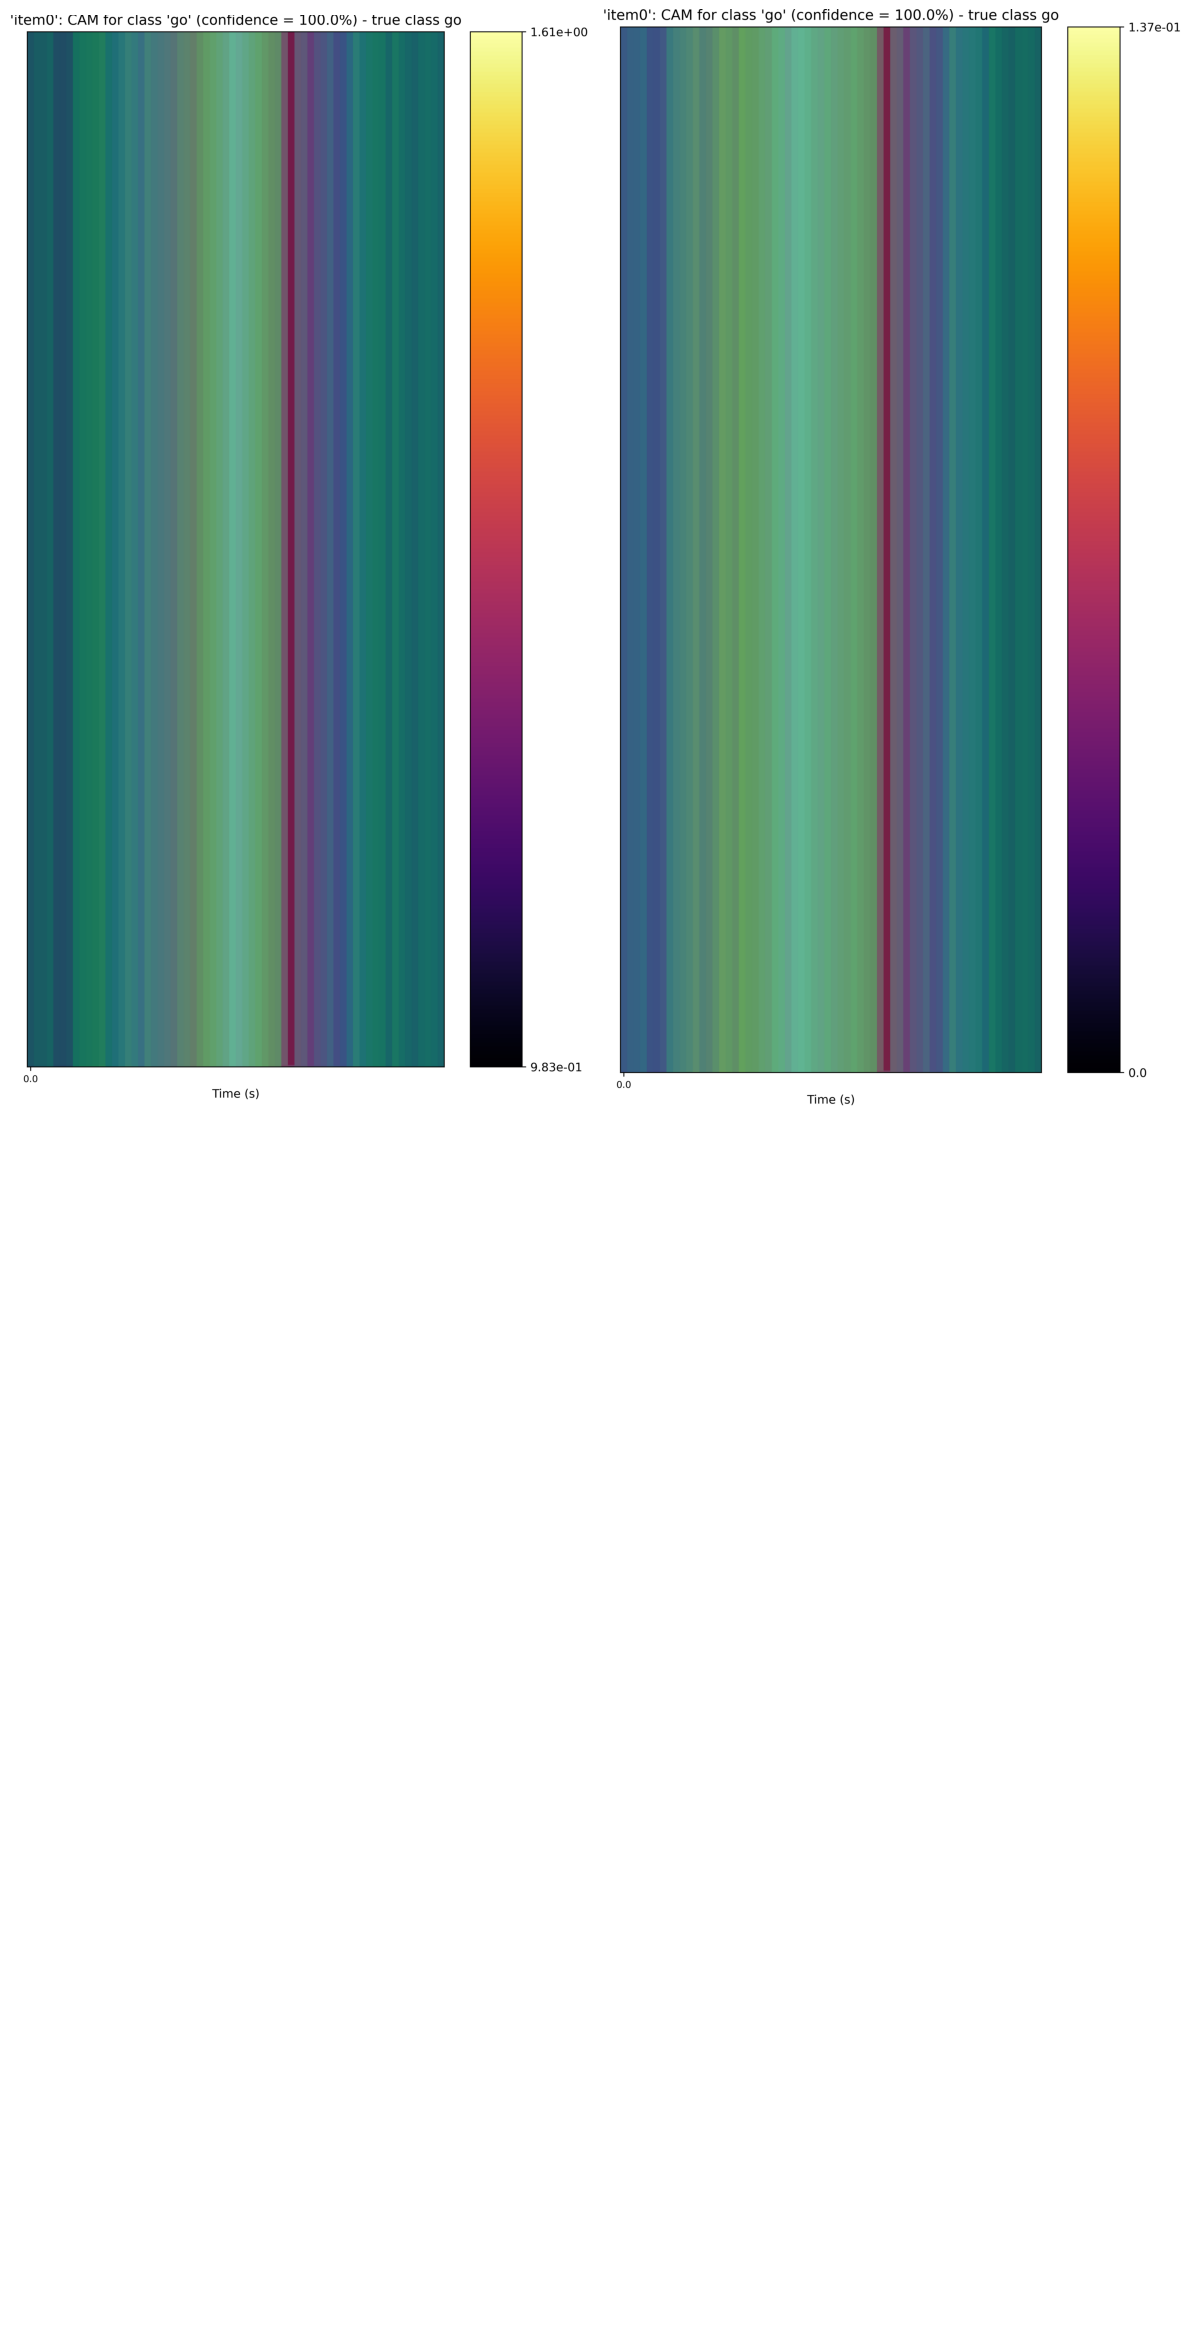

In [19]:
# CAM "GO"
cam_baseline = next(Path(f"/mnt/data/GSC/XAI/00-baseline_resnet18/CAMs/overlays/0-2/item0/").glob("*layer4_1_conv2*.png"), None)
cam_exp = next(Path(f"{xai_path}/CAMs/overlays/0-2/item0/").glob("*layer4_1_conv2*.png"), None)

images_to_show = [cam_baseline, cam_exp]
show_image_grid(images_to_show, cols=2, figsize=(12,24))

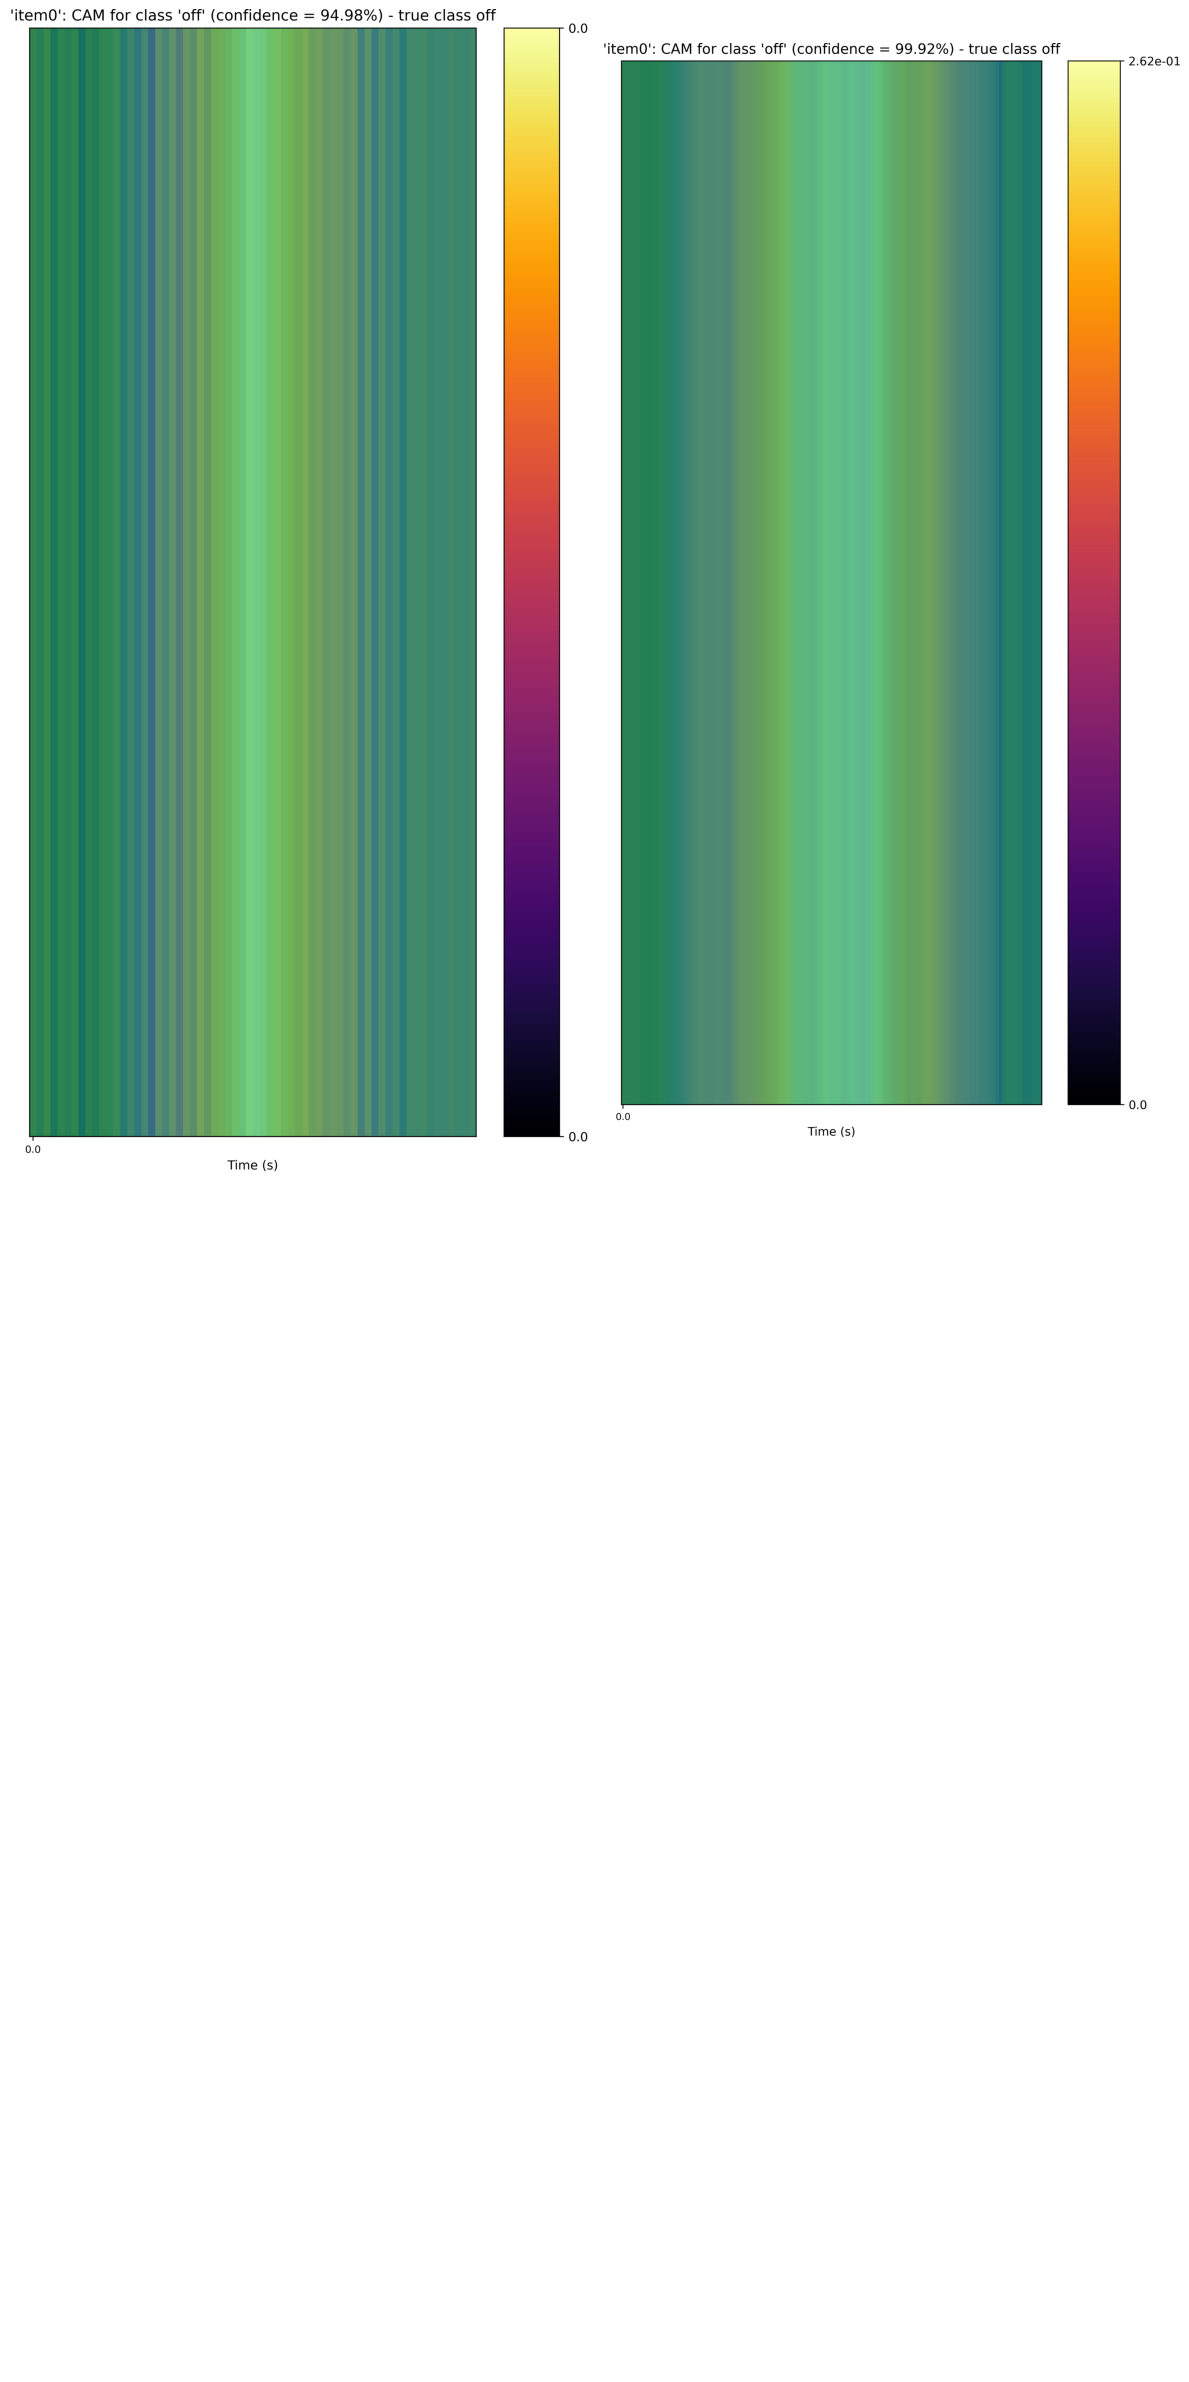

In [20]:
# CAM "OFF"
cam_baseline = next(Path(f"/mnt/data/GSC/XAI/00-baseline_resnet18/CAMs/overlays/0-2/item1/").glob("*layer4_1_conv2*.png"), None)
cam_exp = next(Path(f"{xai_path}/CAMs/overlays/0-2/item1/").glob("*layer4_1_conv2*.png"), None)

images_to_show = [cam_baseline, cam_exp]
show_image_grid(images_to_show, cols=2, figsize=(12,24))

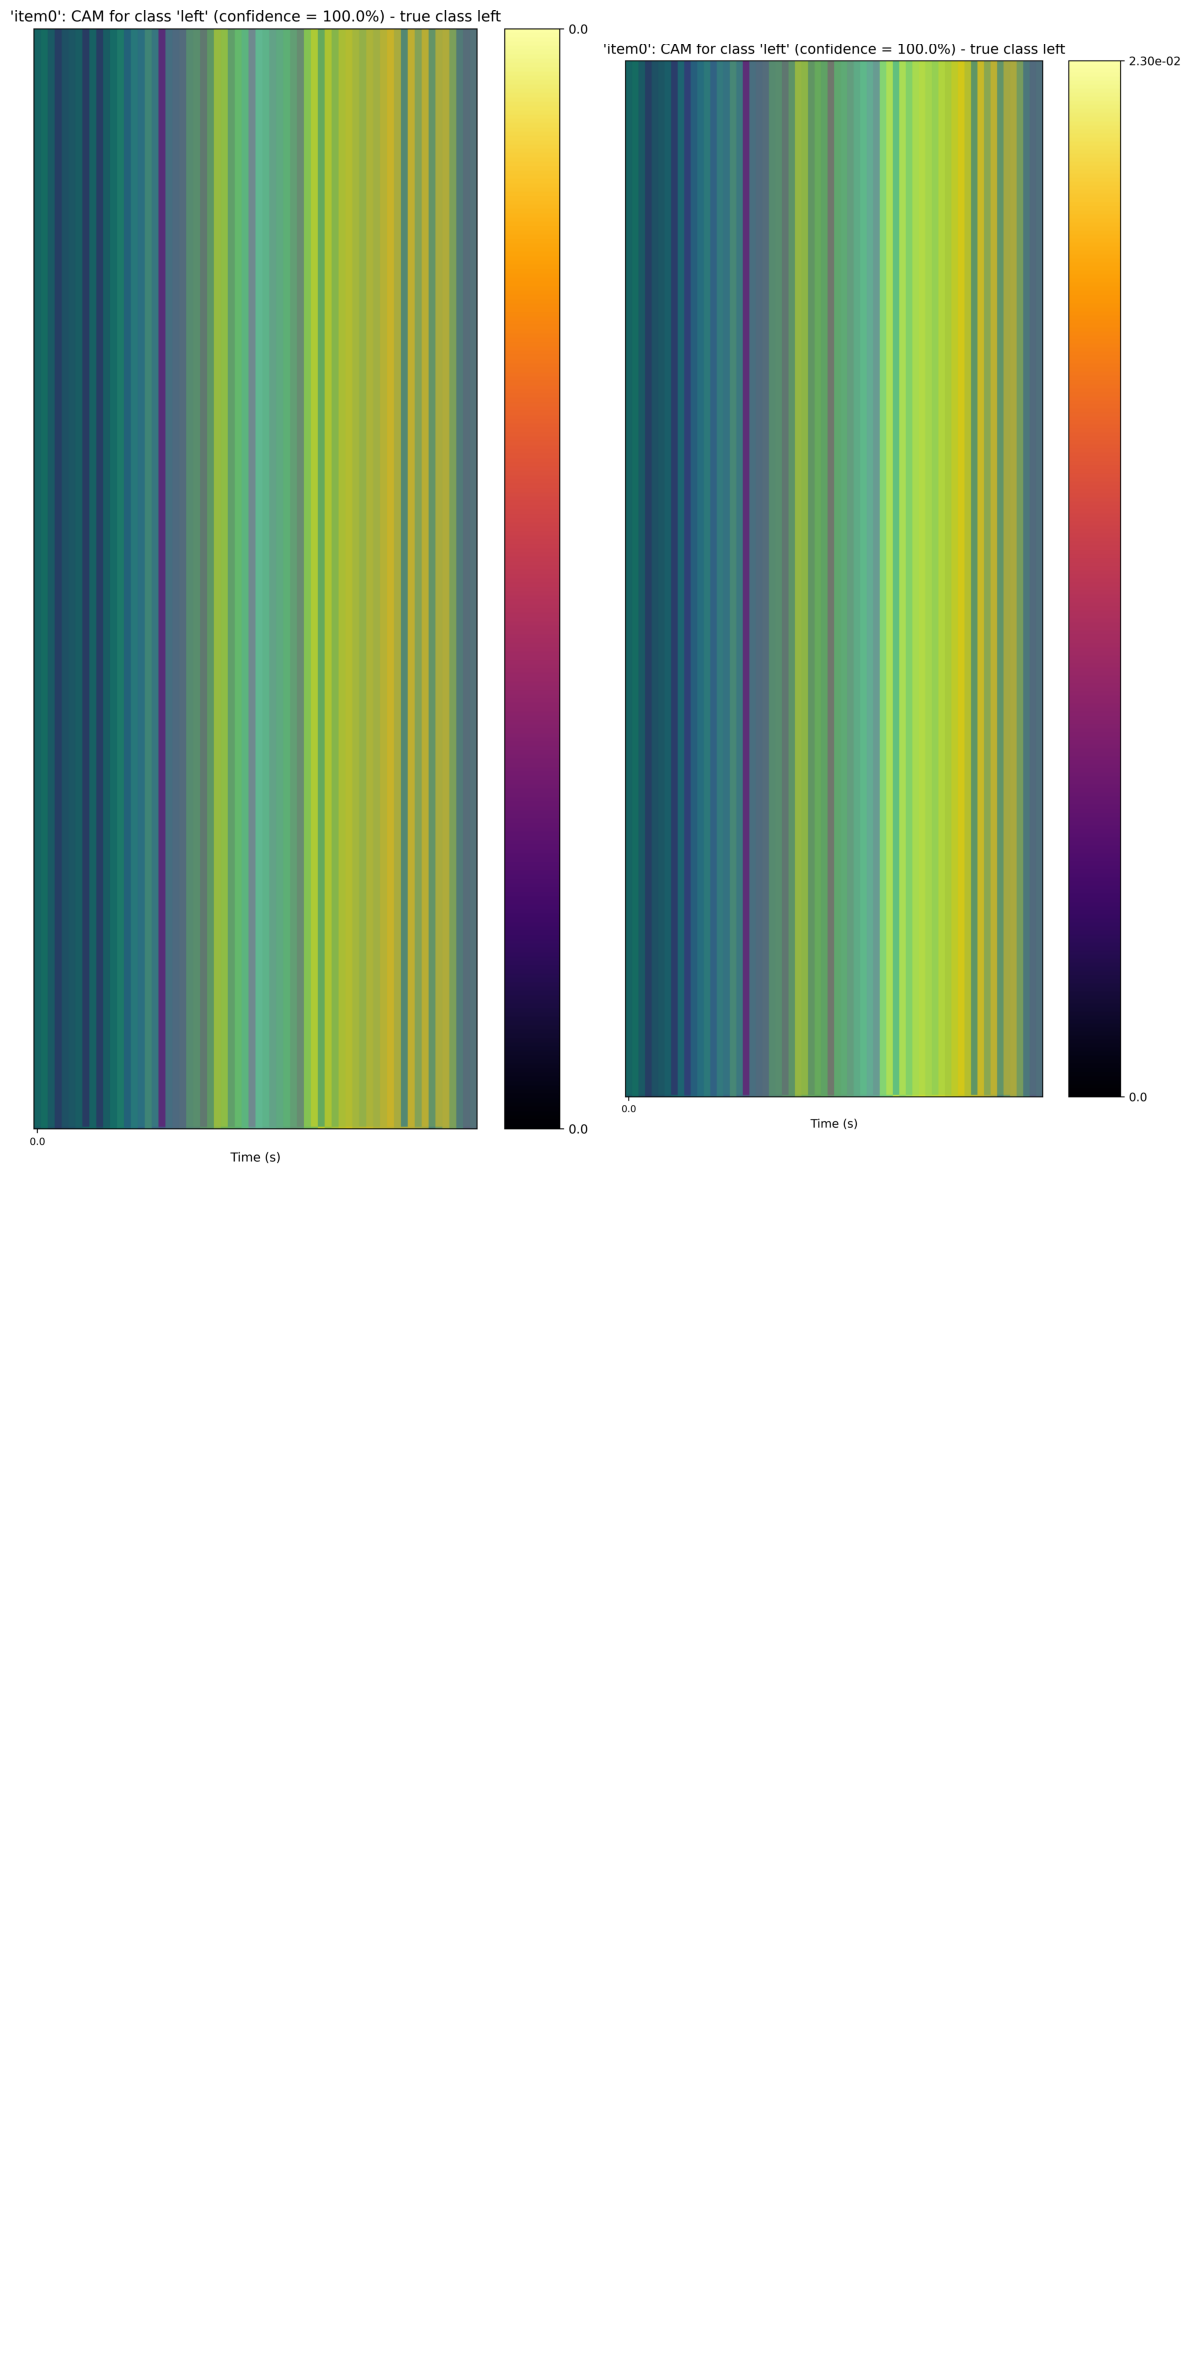

In [20]:
# CAM "LEFT"
cam_baseline = next(Path(f"/mnt/data/GSC/XAI/00-baseline_resnet18/CAMs/overlays/0-2/item2/").glob("*layer4_1_conv2*.png"), None)
cam_exp = next(Path(f"{xai_path}/CAMs/overlays/0-2/item2/").glob("*layer4_1_conv2*.png"), None)

images_to_show = [cam_baseline, cam_exp]
show_image_grid(images_to_show, cols=2, figsize=(12,24))

El resultado es adecuado, pero a pesar del sesgo que hemos introducido en el modelo, con esta representación de 64 bins el modelo sigue prestando más atención a la envolvente temporal. Con este mismo modelo y la representación anterior se desestimó el entrenamiento porque el coste computacional era extremadamente alto.

In [21]:
%%capture
## Generamos los CAMs
target_layers = ['layer4.1.conv2', 'layer4.0.conv2', 
                 'layer3.1.conv2', 'layer3.0.conv2', 
                 'layer2.1.conv2', 'layer1.1.conv2']

explainer = "HiResCAM"

signal_grad_cam_overlays2d(model=loaded_model, dataloader=reference_loader, preprocessor=preprocessor_test,
                          xai_path=xai_path, label_names=label_names, explainer=explainer,
                          target_layers=target_layers, target_classes=reference_labels, 
                          targets_list=reference_targets)

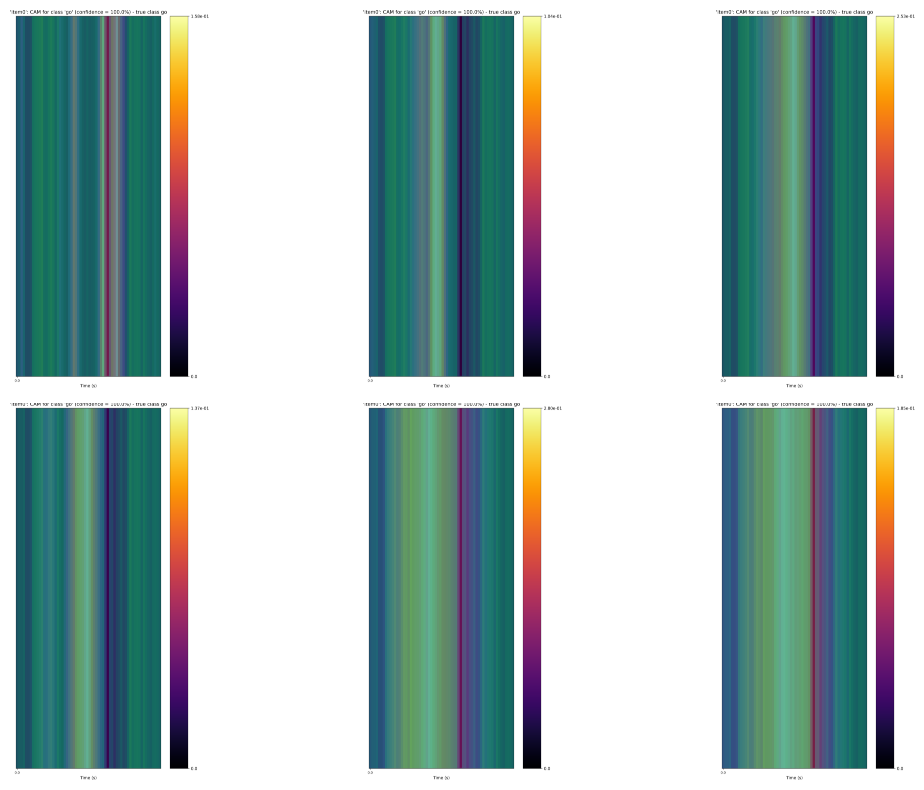

In [22]:
## Visualizamos
# "GO"
images_to_show = sorted(Path(f"{xai_path}/CAMs/overlays/0-2/item0/").glob("*HiRes*.png"))
show_image_grid(images_to_show)

Finalmente, vamos a estimar el coste de entrenamiento a partir del tiempo medio por epoch.

In [23]:
loaded_pt = torch.load(f"{final_path}/final_model.pt", map_location=DEVICE)
etimes = loaded_pt['history'].get('epoch_time')
avg_etime = sum(etimes)/len(etimes)
print(avg_etime)

1111.9508128166199


El coste de entrenamiento se multiplica por 19.75 con respecto de la línea de base, lo que es demasiado. Tras estas pruebas se llega a una serie de conclusiones: 

- Para esta tarea el modelo tiende a relativizar la información frecuencial con respecto de la envolvente temporal y el modelo tiene un muy buen comportamiento con esta naturaleza.
- El ajuste del modelo hacia las componentes frecuenciales es computacionalmente mucho más complejo por las dimensiones de la representación y por los pasos más finos de convolución que han de desarrollarse.
- Una combinación que se intuye equilibrada para los experimentos por eficiencia es utilizar el modelo original con la primera capa de convolución adaptada a 1 canal y la representación de espectrograma del experimento 2. Tomaremos esta base para probar las aumentaciones y luego decidiremos con los datos si realizar el entrenamiento final con alguna adaptación de las capas del modelo.